# Handling missing data using mean-median imputation

In [14]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [16]:
df =pd.read_csv("/home/ipartzix/AI-ML-ENGINEERING-JOURNEY/03_Machine_Learning/02_Feature_Engineering/titanic_toy.csv")

In [17]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [18]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [19]:
X= df.drop(columns=["Survived"])
y=df[["Survived"]]

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [21]:
X_train.shape ,y_train.shape

((712, 3), (712, 1))

In [22]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [23]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [24]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
408,21.0,7.7750,0,21.00,21.000000,7.7750,7.775000
360,40.0,27.9000,5,40.00,40.000000,27.9000,27.900000
828,NaN,7.7500,0,28.75,29.785904,7.7500,7.750000
82,NaN,NaN,0,28.75,29.785904,14.4583,32.617597
821,27.0,8.6625,0,27.00,27.000000,8.6625,8.662500


In [25]:
print('Original Age variable variance: - mean-median-imputation.ipynb:1', X_train['Age'].var())
print('Age Variance after median imputation: - mean-median-imputation.ipynb:2', X_train['Age_median'].var())
print('Age Variance after mean imputation: - mean-median-imputation.ipynb:3', X_train['Age_mean'].var())

print('Original Fare variable variance: - mean-median-imputation.ipynb:5', X_train['Fare'].var())
print('Fare Variance after median imputation: - mean-median-imputation.ipynb:6', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: - mean-median-imputation.ipynb:7', X_train['Fare_mean'].var())

Original Age variable variance: - mean-median-imputation.ipynb:1 204.34951339046142
Age Variance after median imputation: - mean-median-imputation.ipynb:2 161.98956633460548
Age Variance after mean imputation: - mean-median-imputation.ipynb:3 161.81262452718676
Original Fare variable variance: - mean-median-imputation.ipynb:5 2448.1979137063163
Fare Variance after median imputation: - mean-median-imputation.ipynb:6 2340.09102197536
Fare Variance after mean imputation: - mean-median-imputation.ipynb:7 2324.2385256705534


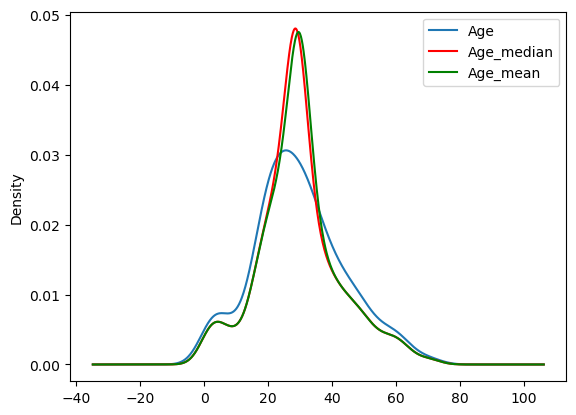

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')